In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tqdm as tqdm

mpl.rc("figure", dpi = 150)
mpl.rc("figure", figsize = (3,2))

In [2]:
probabilities = np.array([
    [np.nan, 1/6, 1/5, 1/3],
    [1/3, np.nan, 2/9, 1/3],
    [1/7, 0, np.nan, 1/5],
    [0, 0, 1/7, np.nan]])

probabilities[np.isnan(probabilities)] = 0
probabilities = probabilities + (np.diag(1-np.sum(probabilities, axis = 1)))

In [3]:
probabilities[np.array([1,2,3])-1,:]

array([[0.3       , 0.16666667, 0.2       , 0.33333333],
       [0.33333333, 0.11111111, 0.22222222, 0.33333333],
       [0.14285714, 0.        , 0.65714286, 0.2       ]])

In [4]:
np.random.choice([1,2,3,4], 1, p = probabilities[1,:])

array([1])

In [5]:
def run_sim(N):
    omega = [1,2,3,4]
    sgm = [1]

    for i in range(N):
        new_state = np.random.choice(omega, 1, p = probabilities[sgm[-1]-1,:])
        sgm.append(new_state[0])
    return np.array(sgm)

In [6]:
r = np.array([run_sim(100) for i in tqdm.tqdm(range(10000))])

100%|████████████████████████████████████████████████████████████████████████| 10000/10000 [00:10<00:00, 969.24it/s]


In [7]:
def count(r):
    return np.array([sum(r==i)/len(r) for i in range(1,5)])

In [8]:
plt.rc('axes', prop_cycle=mpl.cycler('color', ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']))

Text(0, 0.5, '$P(\\sigma)$')

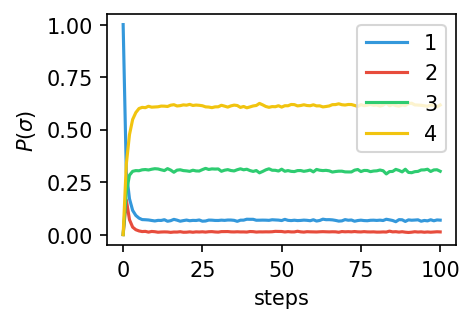

In [9]:
plt.plot(np.array([count(r[:,i]) for i in range(len(r[0,:]))]));
plt.legend([1,2,3,4])
plt.xlabel("steps")
plt.ylabel(r"$P(\sigma)$")

In [10]:
count(r[:,-1])

array([0.0687, 0.0127, 0.3015, 0.6171])

In [11]:
def run_sim(N,p0,p):
    omega = [1,2,3,4]
    sgm = list(np.random.choice(omega, 1, p = p0))

    for i in range(N):
        new_state = np.random.choice(omega, 1, p = p[sgm[-1]-1,:])
        sgm.append(new_state[0])
    return np.array(sgm)

In [12]:
r0 = np.array([run_sim(100, [0,0,1,0], probabilities) for i in tqdm.tqdm(range(10000))])
r1 = np.array([run_sim(100, [0.4,0.2,0.1,0.3], probabilities) for i in tqdm.tqdm(range(10000))])

100%|████████████████████████████████████████████████████████████████████████| 10000/10000 [00:10<00:00, 941.93it/s]


Text(0, 0.5, '$P(\\sigma)$')

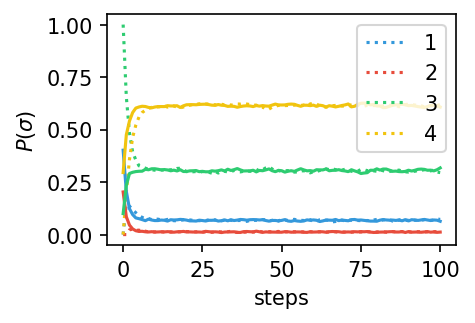

In [13]:
plt.rc('axes', prop_cycle=mpl.cycler('color', ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']))

plt.plot(np.array([count(r0[:,i]) for i in range(len(r[0,:]))]),":");
plt.plot(np.array([count(r1[:,i]) for i in range(len(r[0,:]))]));
plt.legend([1,2,3,4])
plt.xlabel("steps")
plt.ylabel(r"$P(\sigma)$")

(0.0, 25.0)

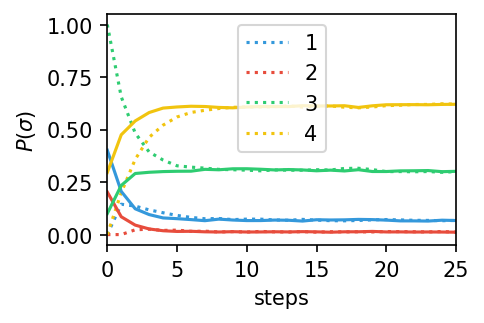

In [14]:
plt.rc('axes', prop_cycle=mpl.cycler('color', ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']))

plt.plot(np.array([count(r0[:,i]) for i in range(len(r[0,:]))]),":");
plt.plot(np.array([count(r1[:,i]) for i in range(len(r[0,:]))]));
plt.legend([1,2,3,4])
plt.xlabel("steps")
plt.ylabel(r"$P(\sigma)$")

plt.xlim(0,25)